# 4.2 OpenOneRec：受约束列表生成实战

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

如何把推荐列表变成 token 序列，同时保证解码结果属于真实目录、没有重复并可接受奖励对齐？

## Setup

默认 `smoke` 档使用仓库内固定版本的 GroupLens **MovieLens latest-small** 真实行为子集，CPU 可重复执行；`full` 档只扩大真实数据规模与训练配置，不切换到合成数据。数据包含真实匿名用户、电影、评分和时间戳；实验只做确定性截取与任务重构，不随机制造交互、标签或行为序列。原始许可与引用保存在 `data/ml-latest-small/README.txt`。

**主要资料：** [Kuaishou OpenOneRec](https://github.com/Kuaishou-OneRec/OpenOneRec)

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import load_movielens, movielens_provenance
real_ratings, real_movies = load_movielens()
REAL_DATASET = movielens_provenance(real_ratings)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 26732, 'users_used': 120, 'items_used': 600, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0}}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 如何把推荐列表变成 token 序列，同时保证解码结果属于真实目录、没有重复并可接受奖励对齐？

**先修知识：** 3.0 的向量、概率与损失函数。第一次阅读无需推导梯度，只要能解释输入、输出和形状。

## Paper & Context

OpenOneRec 展示列表生成、奖励模型和偏好优化的开放流程。smoke 档不冒充官方大模型训练，而是复现最关键的数据契约：item 到 Semantic ID、teacher forcing、trie 约束和合法性压力测试。

**来源：** [Kuaishou OpenOneRec](https://github.com/Kuaishou-OneRec/OpenOneRec)

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Math by Hand

自回归分解 $P(y_1,\ldots,y_T|x)=\prod_tP(y_t|y_{<t},x)$，表示每一步根据上下文和已生成 token 预测下一 token。trie 像目录树：前缀 $(1,2)$ 下只允许真实后继 $\{3,4\}$。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

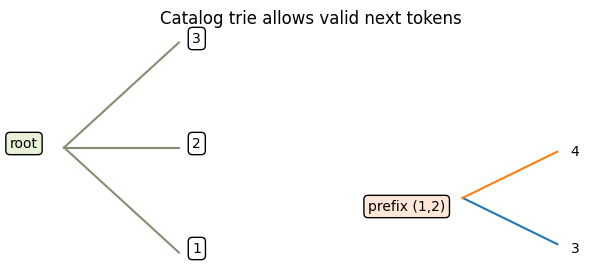

In [2]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(7,3)); ax.axis('off'); ax.text(.05,.5,'root',bbox=dict(boxstyle='round',fc='#e8f2d6'))
for y,node in zip([.25,.5,.75],['1','2','3']):
    ax.text(.32,y,node,bbox=dict(boxstyle='round',fc='white')); ax.plot([.13,.30],[.5,y],color='#809070')
ax.text(.58,.35,'prefix (1,2)',bbox=dict(boxstyle='round',fc='#ffe8d7')); ax.text(.88,.25,'3'); ax.text(.88,.48,'4')
ax.plot([.72,.86],[.38,.27]); ax.plot([.72,.86],[.38,.49]); ax.set_title('Catalog trie allows valid next tokens'); plt.show()

## Data

MovieLens 真实电影 metadata 生成 Semantic ID；真实高评分行为提供训练码序列，真实高/低评分电影构成 chosen/rejected 示例。

**防泄漏清单：**按时间切分；词表只由训练期建立；负样本来自已观察低评分；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

OpenOneRec 官方训练配置负责 full profile；本 Notebook 的 PyTorch 小生成器验证相同 token/trie 契约、训练损失和合法性。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from recsys_lab.industrial_experiments import run_openonerec, save_records

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_openonerec))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_openonerec(epochs: int = 32) -> dict:
    seed_everything(); ratings, _, provenance = _real_ratings(); item_to_code = _semantic_catalog(ratings); catalog = set(item_to_code.values())
    positive = ratings[ratings.rating >= 4.0].sort_values("timestamp").tail(1600)
    sequences = np.asarray([item_to_code[int(item)] for item in positive.item_id], dtype=np.int64)
    vocabulary_size = int(sequences.max()) + 2
    model_input = torch.tensor(np.c_[np.zeros((len(sequences), 1), dtype=np.int64), sequences[:, :-1]])
    target = torch.tensor(sequences); model = TinyListGenerator(vocabulary_size); optimizer = torch.optim.Adam(model.parameters(), lr=.02); losses=[]
    for _ in range(epochs):
        logits = model(model_input); loss = torch.nn.functional.cross_entropy(logits.reshape(-1, logits.shape[-1]), target.reshape(-1))
        optimizer.zero_grad(); loss.backward(); optimizer.step(); losses.append(float(loss.detach()))
    prefix_counts = {}
    for code 

## Train & Inference

下一格实际执行完整 smoke：固定 seed、构造数据、实例化模型、训练、切换到推理路径并计算测试指标。

In [4]:
result = run_openonerec()
print({'framework': result['framework'], 'dataset': result.get('dataset', {})})
print('inference contract:', '自回归每一步应用目录 trie、去重和长度约束；随后可用奖励模型或 DPO 调整整列价值。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

{'framework': 'OpenOneRec contract + PyTorch executable proxy', 'dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 20241, 'users_used': 96, 'items_used': 480, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0, 'semantic_catalog_size': 322, 'training_codes': 1600, 'code_source': 'real genre + release decade + movie id'}}
inference contract: 自回归每一步应用目录 trie、去重和长度约束；随后可用奖励模型或 DPO 调整整列价值。
loss: 3.52 → 2.0734


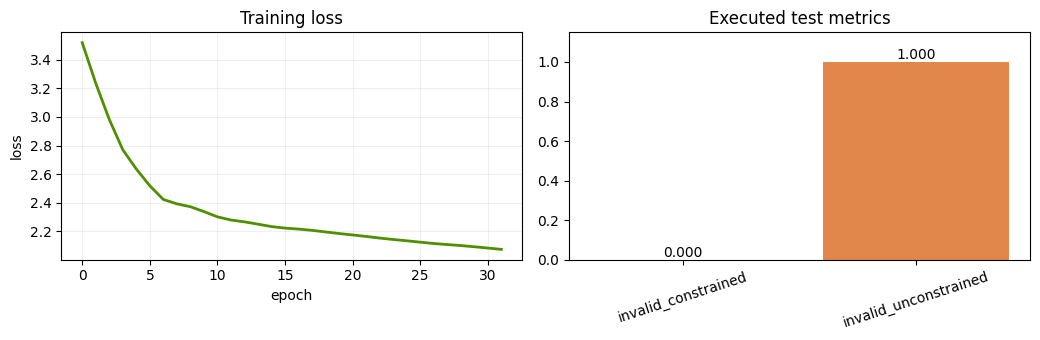

,value
invalid_constrained,0.0
invalid_unconstrained,1.0


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'invalid_constrained': result['invalid_constrained'], 'invalid_unconstrained': result['invalid_unconstrained']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

## Test & Results Discussion

In [6]:
display(Markdown(f'''### 本次已执行结果

- 主指标 invalid_constrained = **{result['invalid_constrained']:.4f}**。
- 辅助指标 invalid_unconstrained = **{result['invalid_unconstrained']:.4f}**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 合法率只是底线，不等于相关性；还需看 Recall/NDCG、重复率、多样性、P99、目录更新和奖励偏差。

### 工业边界

自回归每一步应用目录 trie、去重和长度约束；随后可用奖励模型或 DPO 调整整列价值。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 invalid_constrained = **0.0000**。
- 辅助指标 invalid_unconstrained = **1.0000**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **3.5200** 降到 **2.0734**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 合法率只是底线，不等于相关性；还需看 Recall/NDCG、重复率、多样性、P99、目录更新和奖励偏差。

### 工业边界

自回归每一步应用目录 trie、去重和长度约束；随后可用奖励模型或 DPO 调整整列价值。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [7]:
record={
    'algorithm': 'OpenOneRec：受约束列表生成实战',
    'primary_metric': 'invalid_constrained', 'primary_value': float(result['invalid_constrained']),
    'secondary_metric': 'invalid_unconstrained', 'secondary_value': float(result['invalid_unconstrained']),
    'baseline_metric': None,
    'baseline_value': float(result[None]) if False else None,
    'framework': result['framework'], 'source_notebook': '4_2_openonerec_practice',
    'dataset': 'MovieLens latest-small',
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_4','4_2_openonerec_practice',[record]); print('saved:',path.relative_to(ROOT))

saved: results/chapter_4/4_2_openonerec_practice.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [8]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['invalid_constrained']) <= 1
assert np.isfinite(float(result['invalid_unconstrained']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。